# Latent Similarity Analysis
Semantic similarity between original English poem verses and their Google Translate Turkish translations.

**Sample:** 12 Positive · 12 Negative · 3 Neutral · 3 Mixed verses from `poem_sentiment`

**Method:** Cosine similarity in the multilingual sentence embedding space + PCA visualization

## 0. Install Dependencies

In [32]:
!pip install sentence-transformers googletrans==4.0.0rc1 datasets

## 1. Imports & Configuration

In [33]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sentence_transformers import SentenceTransformer, util
from googletrans import Translator
from datasets import load_dataset, concatenate_datasets

# ── Config ────────────────────────────────────────────────────────────────────
SBERT_MODEL  = 'paraphrase-multilingual-MiniLM-L12-v2'
SAMPLE_COUNTS = {0: 10, 1: 10, 2: 5, 3: 3}  # {label: n_samples}
RANDOM_SEED  = 21

LABEL_NAMES = {
    0: 'Negative',
    1: 'Positive',
    2: 'No Impact',
    3: 'Mixed',
}
COLORS = {0: 'red', 1: 'green', 2: 'gray', 3: 'orange'}


## 2. Load & Sample Dataset

In [34]:
dataset = load_dataset('poem_sentiment')

# Combine all splits so we have more candidates to sample from
full_data = concatenate_datasets([dataset['train'], dataset['validation'], dataset['test']])
print(f'Total verses: {len(full_data)}')

# Sample n verses per label
np.random.seed(RANDOM_SEED)
sampled_rows = []

for label, n in SAMPLE_COUNTS.items():
    pool = [item for item in full_data if item['label'] == label]
    chosen = np.random.choice(len(pool), size=n, replace=False)
    for idx in chosen:
        sampled_rows.append({
            'english_verse': pool[idx]['verse_text'],
            'label': label,
        })

df = pd.DataFrame(sampled_rows).reset_index(drop=True)
print(f'Sampled {len(df)} verses:')
print(df['label'].value_counts().sort_index().rename(LABEL_NAMES))


Total verses: 1101
Sampled 28 verses:
label
Negative     10
Positive     10
No Impact     5
Mixed         3
Name: count, dtype: int64


## 3. Translate: English → Turkish

`googletrans` uses the Google Translate API under the hood. A small `time.sleep` between requests avoids rate-limiting.

In [35]:
translator = Translator()
turkish_verses = []

print('Translating...')
for i, row in df.iterrows():
    result = translator.translate(row['english_verse'], src='en', dest='tr')
    turkish_verses.append(result.text)
    time.sleep(0.15)  # gentle throttle
    if (i + 1) % 10 == 0:
        print(f'  {i + 1}/{len(df)} done')

df['turkish_verse'] = turkish_verses
print('Translation complete.')
df[['english_verse', 'turkish_verse', 'label']].head(5)


Translating...
  10/28 done
  20/28 done
Translation complete.


,english_verse,turkish_verse,label
0,"but o, nevermore can we prison him tight.","ama ah, onu artık asla sıkı tutamayız.",0
1,"blood-dipped arrows, which savages make",vahşilerin yaptığı kana bulanmış oklar,0
2,none will forget it till shall fall the deadly...,Ölümcül ok düşene kadar kimse bunu unutmayacak!,0
3,"what gods, what madness, hither steer’d your c...","Hangi tanrılar, hangi çılgınlık rotanızı buray...",0
4,"ah, what a pang of aching sharp surprise","ah, ne acı, keskin bir sürpriz sancısı",0


## 4. Compute Semantic Embeddings & Cosine Similarity

In [36]:
print(f'Loading SBERT model: {SBERT_MODEL}')
sbert = SentenceTransformer(SBERT_MODEL)

embeddings_en = sbert.encode(df['english_verse'].tolist(), convert_to_tensor=True)
embeddings_tr = sbert.encode(df['turkish_verse'].tolist(), convert_to_tensor=True)
print('Embeddings computed. Shape:', tuple(embeddings_en.shape))

similarities = [
    util.cos_sim(embeddings_en[i], embeddings_tr[i]).item()
    for i in range(len(df))
]
df['cosine_similarity'] = similarities


Loading SBERT model: paraphrase-multilingual-MiniLM-L12-v2
Embeddings computed. Shape: (28, 384)


## 5. Results
### 5.1 Mean Similarity by Sentiment Label

--- Mean Cosine Similarity by Label ---

             Mean     Std     Min     Max
label                                    
Negative   0.7793  0.0553  0.7011  0.8877
Positive   0.7915  0.1551  0.4341  0.9635
No Impact  0.8927  0.0735  0.8113  0.9659
Mixed      0.8205  0.0495  0.7705  0.8695


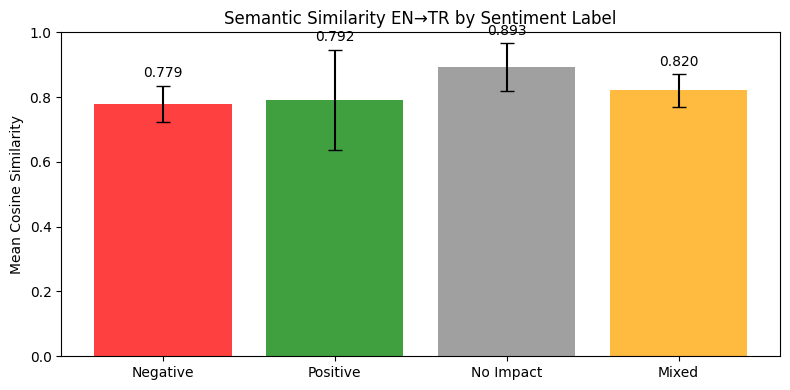

In [37]:
print('--- Mean Cosine Similarity by Label ---\n')
grouped = df.groupby('label')['cosine_similarity'].agg(['mean', 'std', 'min', 'max'])
grouped.index = grouped.index.map(LABEL_NAMES)
grouped.columns = ['Mean', 'Std', 'Min', 'Max']
print(grouped.round(4).to_string())

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
colors_list = [COLORS[k] for k in sorted(SAMPLE_COUNTS)]
bars = ax.bar(grouped.index, grouped['Mean'], color=colors_list, alpha=0.75,
              yerr=grouped['Std'], capsize=5)
ax.set_ylim(0, 1)
ax.set_ylabel('Mean Cosine Similarity')
ax.set_title('Semantic Similarity EN→TR by Sentiment Label')
ax.bar_label(bars, fmt='%.3f', padding=4)
plt.tight_layout()
plt.show()


### 5.2 Samples with Lowest Similarity
*(Verses where emotion is most likely lost in translation)*

In [38]:
print('--- 5 Verses with Lowest Cosine Similarity ---\n')
lowest = df.sort_values('cosine_similarity').head(5)

for _, row in lowest.iterrows():
    print(f"Label       : {row['label']} ({LABEL_NAMES[row['label']]})")
    print(f"English     : {row['english_verse']}")
    print(f"Turkish     : {row['turkish_verse']}")
    print(f"Similarity  : {row['cosine_similarity']:.4f}")
    print('-' * 60)


--- 5 Verses with Lowest Cosine Similarity ---

Label       : 1 (Positive)
English     : make a fragrance of her fame.
Turkish     : şöhretinin kokusunu yarat.
Similarity  : 0.4341
------------------------------------------------------------
Label       : 1 (Positive)
English     : sometimes towards heav'n and the full-blazing sun,
Turkish     : bazen cennete ve yakıcı güneşe doğru,
Similarity  : 0.6896
------------------------------------------------------------
Label       : 0 (Negative)
English     : but o, nevermore can we prison him tight.
Turkish     : ama ah, onu artık asla sıkı tutamayız.
Similarity  : 0.7011
------------------------------------------------------------
Label       : 1 (Positive)
English     : thy hands all cunning arts that women prize.
Turkish     : Kadınların değer verdiği tüm kurnaz sanatlar senin ellerinde.
Similarity  : 0.7287
------------------------------------------------------------
Label       : 0 (Negative)
English     : when the glance hast lost its

## 6. PCA Visualization
Project all 384-dim vectors to 2D. English = circle (`o`), Turkish = cross (`x`). Dashed lines connect translation pairs.

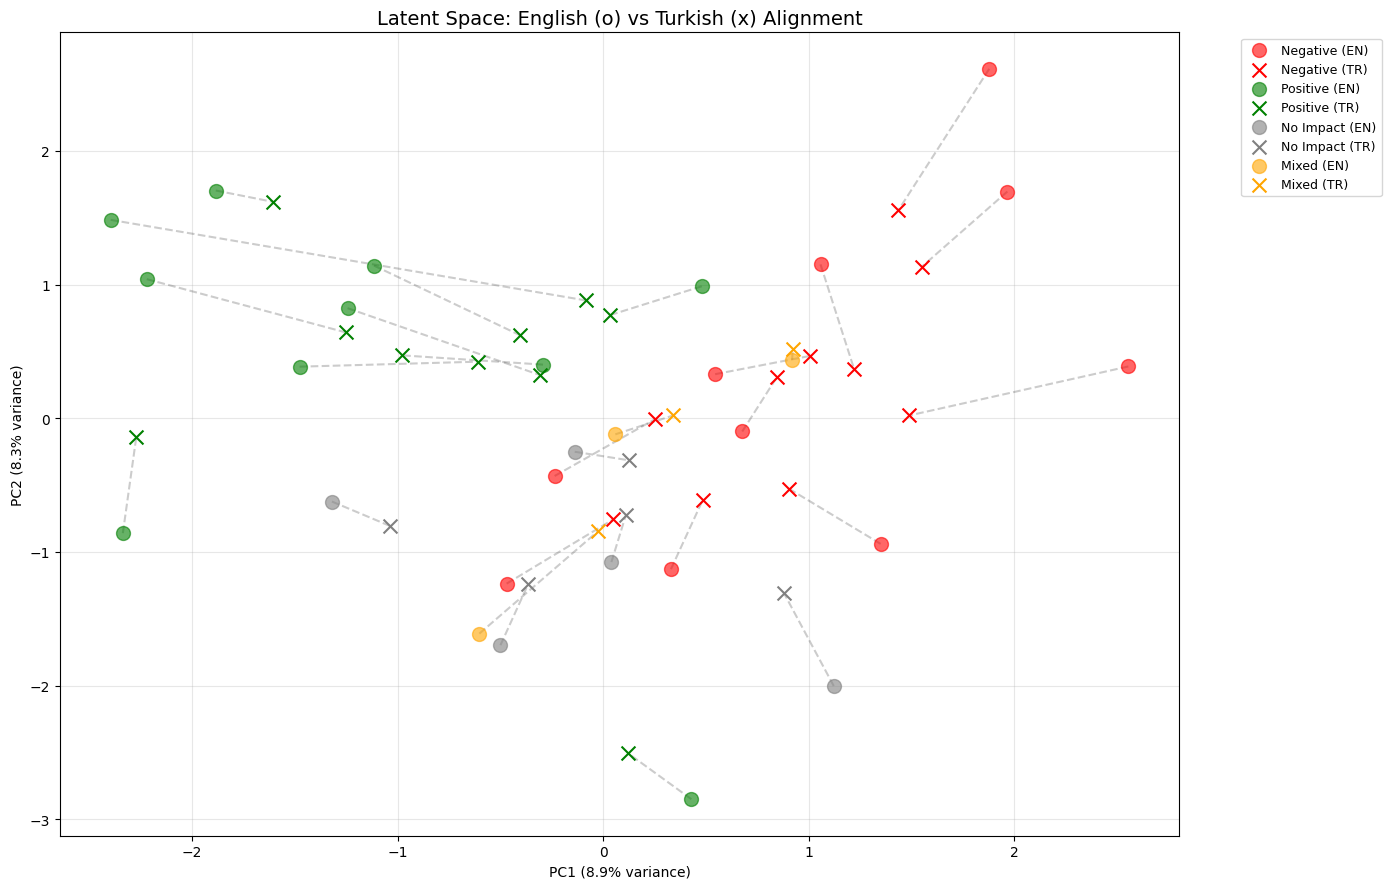

In [39]:
# Fit PCA on EN + TR together so both live in the same 2D space
pca = PCA(n_components=2, random_state=RANDOM_SEED)
all_embeddings = np.vstack([
    embeddings_en.cpu().numpy(),
    embeddings_tr.cpu().numpy(),
])
pca_results = pca.fit_transform(all_embeddings)

n = len(df)
pca_en = pca_results[:n]
pca_tr = pca_results[n:]

var_explained = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(14, 9))

for lbl_id, lbl_name in LABEL_NAMES.items():
    idx = df[df['label'] == lbl_id].index.tolist()
    if not idx:
        continue
    color = COLORS[lbl_id]

    ax.scatter(pca_en[idx, 0], pca_en[idx, 1],
               c=color, marker='o', s=100,
               label=f'{lbl_name} (EN)', alpha=0.6, zorder=3)
    ax.scatter(pca_tr[idx, 0], pca_tr[idx, 1],
               c=color, marker='x', s=100,
               label=f'{lbl_name} (TR)', zorder=3)

    for i in idx:
        ax.plot([pca_en[i, 0], pca_tr[i, 0]],
                [pca_en[i, 1], pca_tr[i, 1]],
                c='black', linestyle='--', alpha=0.2, zorder=2)

ax.set_title('Latent Space: English (o) vs Turkish (x) Alignment', fontsize=14)
ax.set_xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Interpretation

It suggests Google Translate
preserves **surface-level semantics** reasonably well. However, a closer look reveals a
consistent pattern: **emotionally polar verses drift further from their originals**.

**Bar chart:**
Negative and Positive labels score the lowest mean similarity,
while No Impact scores the highest.
This suggests that neutral, descriptive language translates more faithfully than
emotionally charged language. Sentiment-carrying words (grief, sorrow, joy, delight)
tend to have weaker cross-lingual lexical anchors, and their connotations shift
more in translation.

**PCA plot:**
The dashed lines connecting English (○) and Turkish (×) pairs make the drift visible
in latent space. Neutral/No Impact pairs (gray) tend to stay close together near the
center of the plot. Polar pairs — particularly Negative (red) and Positive (green) —
show longer connector lines. A few Positive EN points in the upper-left cluster
have their Turkish counterparts displaced significantly downward and rightward,
crossing into emotionally ambiguous territory.

**Takeaway:**
Standard NMT handles *what* is said better than *how it feels*. The stronger the
emotional valence of a verse, the more likely translation is to flatten or shift it —
which is precisely the motivation for our next phases.